# Xử lý dữ liệu CV - CuCoMOF Glucose Sensor
Dataset gồm các đường cong Cyclic Voltammetry (CV) đo cường độ dòng điện (µA) theo điện thế (V) tại các nồng độ glucose khác nhau.

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Đọc dữ liệu thô

File CSV dùng tab (`\t`) làm separator, có 2 dòng header và một số dòng có tab kép (dữ liệu bị lệch cột). Cần đọc thủ công để xử lý.

In [2]:
concentrations = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]  # mM

data_rows = []
with open("CUCOMOF.csv", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        line = line.strip()
        # Bỏ dòng trống và 3 dòng header đầu
        if not line or i in [0, 1, 2]:
            continue
        parts = [p.strip() for p in line.split('\t')]
        # Lọc bỏ chuỗi rỗng do tab kép
        clean = [p for p in parts if p != '']
        if len(clean) >= 11:
            clean = clean[:11]
        else:
            clean += [np.nan] * (11 - len(clean))
        data_rows.append(clean)

df_raw = pd.DataFrame(data_rows, columns=['V'] + [f'{c}mM' for c in concentrations])
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

print(f"Kích thước dữ liệu thô: {df_raw.shape}")
print(f"V range: {df_raw['V'].min():.3f} → {df_raw['V'].max():.3f} V")
df_raw.head()

Kích thước dữ liệu thô: (200, 11)
V range: -0.200 → 0.799 V


,V,0.5mM,1.0mM,1.5mM,2.0mM,2.5mM,3.0mM,3.5mM,4.0mM,4.5mM,5.0mM
0,-0.20004,-22.86434,-8.13007,-8.13007,-5.79357,-10.89573,-6.93798,-6.89030,-6.46114,-6.98566,-6.65188
1,-0.19004,-13.66138,-4.69685,-4.69685,-3.21865,-6.36578,-3.93391,-3.88622,-3.60012,-3.93391,-3.74317
2,-0.18004,-9.94205,-3.21865,-3.21865,-2.12193,-4.50611,-2.64645,-2.64645,-2.40803,-2.69413,-2.50340
3,-0.17004,-7.79629,-2.36034,-2.36034,-1.50204,-3.40939,-1.93119,-1.93119,-1.74046,-1.93119,-1.78814
4,-0.16004,-6.41346,-1.83582,-1.83582,-1.07288,-2.69413,-1.45435,-1.40667,-1.26362,-1.45435,-1.31130


## 3. Lọc chiều quét đi (-0.2V → 0.8V)

Dữ liệu CV gồm 2 chiều: đi (-0.2 → 0.8V) và về (0.8 → -0.2V). Chỉ lấy chiều đi (100 điểm đầu tiên đến V_max).

In [3]:
v_max_idx = df_raw['V'].idxmax()
print(f"V max tại index {v_max_idx}: {df_raw['V'][v_max_idx]:.3f} V")

df_forward = df_raw.iloc[:v_max_idx + 1].copy().reset_index(drop=True)
print(f"Chiều đi: {len(df_forward)} điểm")

V max tại index 100: 0.799 V
Chiều đi: 101 điểm


## 4. Làm tròn điện thế về step 0.1V

Chọn các mốc điện thế: -0.2, -0.1, 0.0, 0.1, ..., 0.8V (tổng 11 mốc).

In [4]:
target_V = [round(v, 1) for v in np.arange(-0.2, 0.9, 0.1)]

df_forward['V_rounded'] = df_forward['V'].round(1)
df_filtered = df_forward[df_forward['V_rounded'].isin(target_V)].copy()

# Nếu có nhiều hàng cùng V_rounded, lấy hàng gần nhất với mốc
df_filtered['V_diff'] = abs(df_filtered['V'] - df_filtered['V_rounded'])
df_filtered = (df_filtered
               .sort_values('V_diff')
               .drop_duplicates('V_rounded')
               .sort_values('V_rounded')
               .drop(columns=['V', 'V_diff'])
               .rename(columns={'V_rounded': 'V'})
               .reset_index(drop=True))

print(f"Số mốc điện thế: {len(df_filtered)}")
print(f"V values: {df_filtered['V'].tolist()}")
df_filtered

Số mốc điện thế: 11
V values: [-0.2, -0.1, -0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


,0.5mM,1.0mM,1.5mM,2.0mM,2.5mM,3.0mM,3.5mM,4.0mM,4.5mM,5.0mM,V
0,-22.86434,-8.13007,-8.13007,-5.79357,-10.89573,-6.93798,-6.89030,-6.46114,-6.98566,-6.65188,-0.2
1,-2.64645,-0.16689,-0.16689,0.16689,-0.59605,-0.02384,0.02384,0.07153,-0.02384,0.02384,-0.1
2,0.21458,1.21593,1.21593,1.12057,1.16825,1.21593,1.21593,1.16825,1.16825,1.16825,-0.0
3,3.07560,3.07560,3.07560,2.93255,3.40939,3.26633,3.17097,3.17097,3.36170,3.31402,0.1
4,17.61913,15.95020,15.95020,15.33031,20.24174,18.33439,18.38207,18.28671,19.43111,19.04964,0.2
5,93.24599,95.29639,95.29639,88.81140,116.94479,103.83177,106.12059,104.45166,106.74048,104.59471,0.3
6,349.97607,386.35873,386.35873,372.29205,447.68048,406.76736,424.60107,417.44852,404.33551,397.99356,0.4
7,694.68311,904.25348,904.25348,954.51257,1047.59119,1003.29303,1061.99170,1060.56116,996.37891,999.00153,0.5
8,887.51648,1277.09387,1277.09387,1512.22327,1556.09229,1598.91272,1685.07715,1755.41113,1660.61548,1694.61438,0.6
9,1275.90186,1486.47400,1486.47400,1826.60291,1789.31421,1966.74634,2049.85913,2239.45044,2165.39771,2238.49683,0.7


## 5. Xoay ngang (Transpose)

Chuyển từ dạng `(V × nồng_độ)` sang dạng ML chuẩn: mỗi **hàng = 1 mẫu** (1 nồng độ glucose), mỗi **cột = 1 feature** (cường độ dòng tại điện thế V).

In [5]:
df_final = df_filtered.set_index('V').T.reset_index()
df_final.columns = ['glucose_mM'] + [f'V_{v:.1f}' for v in df_filtered['V'].tolist()]
df_final['glucose_mM'] = df_final['glucose_mM'].str.replace('mM', '').astype(float)

print(f"Số mẫu   : {len(df_final)}")
print(f"Số features: {len(df_final.columns) - 1} (cường độ dòng tại 11 mốc V)")
print(f"Cột y (target): glucose_mM")
df_final

Số mẫu   : 10
Số features: 11 (cường độ dòng tại 11 mốc V)
Cột y (target): glucose_mM


,glucose_mM,V_-0.2,V_-0.1,V_-0.0,V_0.1,V_0.2,V_0.3,V_0.4,V_0.5,V_0.6,V_0.7,V_0.8
0,0.5,-22.86434,-2.64645,0.21458,3.07560,17.61913,93.24599,349.97607,694.68311,887.51648,1275.90186,2441.91650
1,1.0,-8.13007,-0.16689,1.21593,3.07560,15.95020,95.29639,386.35873,904.25348,1277.09387,1486.47400,2391.18091
2,1.5,-8.13007,-0.16689,1.21593,3.07560,15.95020,95.29639,386.35873,904.25348,1277.09387,1486.47400,2391.18091
3,2.0,-5.79357,0.16689,1.12057,2.93255,15.33031,88.81140,372.29205,954.51257,1512.22327,1826.60291,2233.91919
4,2.5,-10.89573,-0.59605,1.16825,3.40939,20.24174,116.94479,447.68048,1047.59119,1556.09229,1789.31421,2181.13330
5,3.0,-6.93798,-0.02384,1.21593,3.26633,18.33439,103.83177,406.76736,1003.29303,1598.91272,1966.74634,2207.35938
6,3.5,-6.89030,0.02384,1.21593,3.17097,18.38207,106.12059,424.60107,1061.99170,1685.07715,2049.85913,2275.83301
7,4.0,-6.46114,0.07153,1.16825,3.17097,18.28671,104.45166,417.44852,1060.56116,1755.41113,2239.45044,2446.54175
8,4.5,-6.98566,-0.02384,1.16825,3.36170,19.43111,106.74048,404.33551,996.37891,1660.61548,2165.39771,2425.70410
9,5.0,-6.65188,0.02384,1.16825,3.31402,19.04964,104.59471,397.99356,999.00153,1694.61438,2238.49683,2541.95679


## 6. Visualize dữ liệu

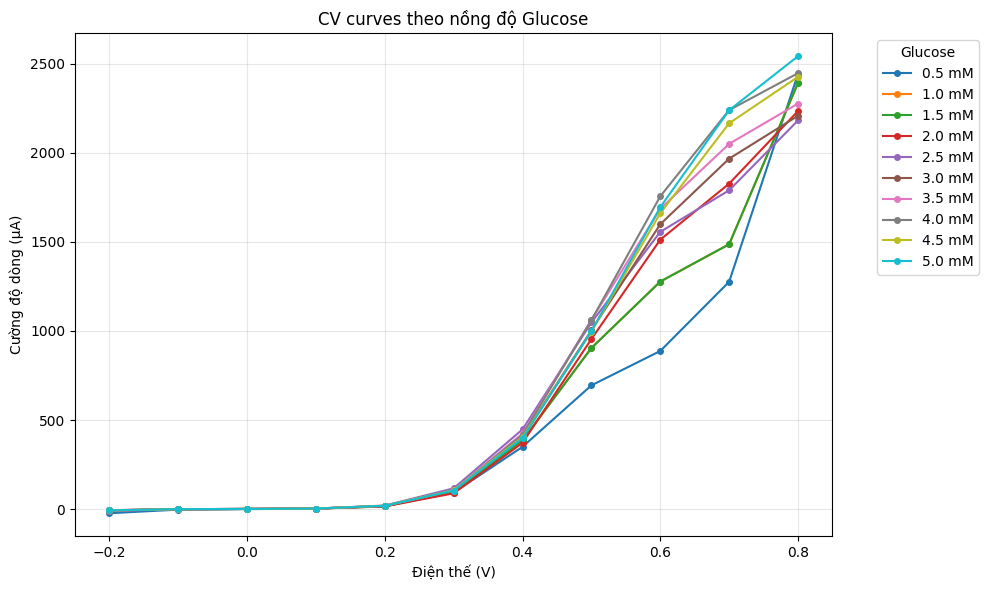

In [6]:
feature_cols = [c for c in df_final.columns if c.startswith('V_')]
v_vals = [float(c.replace('V_', '')) for c in feature_cols]

plt.figure(figsize=(10, 6))
for _, row in df_final.iterrows():
    plt.plot(v_vals, row[feature_cols].values, marker='o', markersize=4,
             label=f"{row['glucose_mM']} mM")

plt.xlabel('Điện thế (V)')
plt.ylabel('Cường độ dòng (µA)')
plt.title('CV curves theo nồng độ Glucose')
plt.legend(title='Glucose', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Lưu file

In [7]:
df_final.to_csv("CUCOMOF_processed.csv", index=False)
print("✅ Đã lưu: CUCOMOF_processed.csv")

✅ Đã lưu: CUCOMOF_processed.csv
